# Topological Data Analysis for Systemic Risk Detection
## A Multi-Market, Multi-Horizon Study with Original Extensions

**Author:** Mauricio Silva López  
**Affiliation:** Actuarial Science & Mathematics, UNAM (FES Acatlán / Facultad de Ciencias)  
**Date:** June 2026

---

### Research question

> *Is the topological L1-norm a superior early warning signal compared to classical risk indicators, and how does that superiority depend on the market and the observation horizon?*

This notebook integrates and **extends** two published frameworks:

| Reference | Contribution |
|-----------|-------------|
| Gidea & Katz (2017), *Physica A* | Multivariate L1-norm of persistence landscapes as EWS for US equity crashes |
| De Jesus et al. (2025), *Neural Computing & Applications* | Per-window TDA features (entropy, amplitude, N) for forecasting |

### Original contributions of this project

| Module | Original question | Method |
|--------|-------------------|--------|
| **1 — Benchmark** | Does L1 detect crashes *earlier* than VIX / rolling correlation / realized vol? | Lead-time analysis across crashes |
| **2 — Emerging markets** | Does topological panic generalize beyond US equities? | IPC Mexico, Bovespa, Merval, COLCAP |
| **3 — TRI index** | Can L1 + entropy + amplitude + N(D) be combined into a single predictive index? | PCA + Logistic Regression |
| **4 — Window sensitivity** | What is the bias–variance trade-off of the observation horizon w? | Grid over w ∈ {25, 50, 75, 100} days |

---

### Pipeline overview

```
Market log-returns (R^d)
        ↓  rolling window w
   Point cloud in R^d
        ↓  Vietoris-Rips filtration
   H1 persistence diagram
        ↓
   L1 norm  ──────────────────────────────→  Module 1: benchmark
   Entropy / Amplitude / N(D)  ──────────→  Module 3: TRI index
        ↓
   Repeat for w ∈ {25,50,75,100}  ───────→  Module 4: sensitivity
   Repeat for EM markets  ────────────────→  Module 2: EM extension
```


---
## Section 0 — Setup and configuration

In [27]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.signal import find_peaks

from ripser import ripser
import pymannkendall as mk

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                             RocCurveDisplay, confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_score

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.25,
    "font.size"         : 10,
    "lines.linewidth"   : 1.6,
})

SEED = 42
np.random.seed(SEED)

# ── Global parameters ─────────────────────────────────────────────────────────
W_BASE   = 50          # baseline window (Gidea & Katz 2017)
W_GRID   = [25, 50, 75, 100]   # Module 4 sensitivity grid
VAR_WIN  = 500         # rolling variance window for EWS
MK_WIN   = 250         # Mann-Kendall pre-crash window

print("Environment ready. Packages: ripser, pymannkendall, sklearn, scipy.")


Environment ready. Packages: ripser, pymannkendall, sklearn, scipy.


---
## Section 1 — Data: calibrated synthetic market simulator

Since the execution environment blocks external network access, we use a
**calibrated synthetic data generator** that reproduces the key statistical
properties of real equity return series (Gidea & Katz 2017, Section 3):

- **Student-t(5) innovations** — fat tails (established stylized fact, Mandelbrot 1963)
- **Two stress episodes** matching the dot-com buildup and Lehman buildup periods,
  with rising cross-correlation (herding) and rising volatility
- **Calm periods** with low correlation and near-normal returns

This is not a limitation: Gidea & Katz themselves validate their method entirely
on synthetic data (Sections 3.2–3.4) before applying it to real data.
When Yahoo Finance is available on your machine, replace `make_market()` with
a `yf.download()` call — the rest of the pipeline is identical.


In [28]:
import yfinance as yf
import pandas as pd
import numpy as np

def fetch_real_market(tickers=['^GSPC', '^DJI', '^IXIC', '^RUT'], 
                      start='1995-01-03', end='2011-12-30'):
    """
    Descarga series de retornos reales de mercado en R^n_series.

    Parameters
    ----------
    tickers : list
        Lista de símbolos de Yahoo Finance. Por defecto:
        S&P 500 (^GSPC), Dow Jones (^DJI), NASDAQ (^IXIC), Russell 2000 (^RUT).
    start : str
        Fecha de inicio (Formato YYYY-MM-DD).
    end : str
        Fecha de fin (Formato YYYY-MM-DD).

    Returns
    -------
    log_ret : DataFrame, shape (T, len(tickers))
        Matriz de log-retornos diarios.
    price_idx : Series
        Índice de precios normalizado (base 1000) para el primer ticker (ej. S&P 500).
    crashes : dict
        {label: Timestamp} fechas exactas de colapsos históricos.
    """
    print(f"Descargando datos reales de Yahoo Finance para: {tickers}...")
    
    # Descargar precios de cierre ajustados
    data = yf.download(tickers, start=start, end=end)['Close']
    
    # 1. Eliminar filas con datos faltantes (días festivos asimétricos)
    # Esto es crítico para mantener la matriz simétrica para la topología
    data = data.dropna()
    
    # 2. Calcular log-retornos continuos: ln(P_t / P_{t-1})
    log_ret = np.log(data / data.shift(1)).dropna()
    
    # Renombrar columnas para mayor claridad
    nombres_indices = ['S&P 500', 'Dow Jones', 'NASDAQ', 'Russell 2000']
    # Asegurar mapeo correcto si se usan los tickers por defecto
    if len(tickers) == 4 and '^GSPC' in tickers:
        log_ret.columns = nombres_indices
        
    # 3. Reconstruir el índice de precios para el primer ticker (normalizado a 1000)
    # Esto mantiene el comportamiento exacto de tu price_idx sintético
    ticker_principal = log_ret.columns[0]
    precio_base = data.iloc[1, 0] # Precio base correspondiente a la primera fila de retornos
    price_idx = (data.loc[log_ret.index].iloc[:, 0] / precio_base) * 1000
    price_idx.name = ticker_principal
    
    # 4. Fechas históricas de los colapsos
    crashes = {
        'Dot-com (2000-03-10)': pd.Timestamp('2000-03-10'),
        'Lehman  (2008-09-15)': pd.Timestamp('2008-09-15'),
    }
    
    return log_ret, price_idx, crashes

# ==========================================
# Generar datos reales del mercado de EE.UU.
# ==========================================
us_ret, us_price, US_CRASHES = fetch_real_market()

print("\nUS Real Market (Gidea & Katz 2018 Assets)")
print(f"  Trading days : {len(us_ret):,}")
print(f"  Date range   : {us_ret.index[0].date()} → {us_ret.index[-1].date()}")
print(f"  Crash dates  : {list(US_CRASHES.keys())}")
print(f"  Daily vol    : {us_ret.std().mean()*100:.2f}% (mean across indices)")
print(f"  Kurtosis     : {us_ret.kurt().mean():.2f} (>3 = fat tails ✓)")

[*********************100%***********************]  4 of 4 completed

Descargando datos reales de Yahoo Finance para: ['^GSPC', '^DJI', '^IXIC', '^RUT']...

US Real Market (Gidea & Katz 2018 Assets)
  Trading days : 4,280
  Date range   : 1995-01-04 → 2011-12-29
  Crash dates  : ['Dot-com (2000-03-10)', 'Lehman  (2008-09-15)']
  Daily vol    : 1.43% (mean across indices)
  Kurtosis     : 6.18 (>3 = fat tails ✓)


---
## Section 2 — TDA core functions

### 2.1 The Vietoris-Rips filtration and persistence landscapes

For each rolling window of $w$ trading days we obtain a **point cloud**
$X_n = \{x_n, x_{n+1}, \ldots, x_{n+w-1}\} \subset \mathbb{R}^d$.

The **Vietoris-Rips complex** $VR(X_n, \varepsilon)$ includes a $k$-simplex
whenever all pairwise distances among its vertices are $< \varepsilon$.
As $\varepsilon$ grows from 0 to $\infty$ a filtration is formed, and
**persistent homology** tracks the birth and death of $k$-dimensional holes.

For $H_1$ (loops), each generator $\alpha$ has a pair $(b_\alpha, d_\alpha)$.
The **first persistence landscape function** is

$$\lambda_1(x) = \max_{(b,d)} f_{(b,d)}(x), \quad
f_{(b,d)}(x) = \begin{cases}
x - b & x \in [b, \tfrac{b+d}{2}] \\\\
d - x & x \in [\tfrac{b+d}{2}, d] \\\\
0 & \text{otherwise}
\end{cases}$$

Its **L1-norm** equals the sum of triangle areas:

$$\|\lambda\|_1 = \sum_i \frac{(d_i - b_i)^2}{4}$$

This is the primary risk metric of Gidea & Katz (2017).

### 2.2 De Jesus et al. (2025) forecasting features

Three additional scalar summaries per diagram:

$$H(D) = -\sum_i p_i \log p_i, \quad p_i = \frac{d_i-b_i}{\sum_j(d_j-b_j)}
\qquad \text{(persistent entropy)}$$

$$A(D) = \max_i(d_i - b_i) \qquad \text{(amplitude)}$$

$$N(D) = |I_q| \qquad \text{(number of off-diagonal points)}$$


In [29]:
def l1_norm(dgm_h1: np.ndarray) -> float:
    """L1-norm of first persistence landscape. Gidea & Katz (2017)."""
    if len(dgm_h1) == 0:
        return 0.0
    fin = dgm_h1[np.isfinite(dgm_h1[:, 1])]
    if len(fin) == 0:
        return 0.0
    lt = fin[:, 1] - fin[:, 0]
    return float(np.sum(lt ** 2) / 4.0)


def tda_features(dgm_h1: np.ndarray) -> tuple:
    """
    Returns (l1, entropy, amplitude, n_points).
    De Jesus et al. (2025) features bundled with L1.
    """
    if len(dgm_h1) == 0:
        return 0.0, 0.0, 0.0, 0
    fin = dgm_h1[np.isfinite(dgm_h1[:, 1])]
    if len(fin) == 0:
        return 0.0, 0.0, 0.0, 0
    lt  = fin[:, 1] - fin[:, 0]
    R   = lt.sum()
    l1  = float(np.sum(lt ** 2) / 4.0)
    if R < 1e-15:
        return l1, 0.0, 0.0, len(fin)
    p   = lt / R
    H   = float(-np.sum(p * np.log(p + 1e-12)))
    A   = float(lt.max())
    N   = int(len(fin))
    return l1, H, A, N


def compute_tda_series(ret_matrix: np.ndarray,
                       dates: pd.DatetimeIndex,
                       window: int = 50) -> pd.DataFrame:
    """
    Rolling TDA computation over a return matrix.

    Parameters
    ----------
    ret_matrix : ndarray, shape (T, d)
    dates      : DatetimeIndex of length T
    window     : int, rolling window w

    Returns
    -------
    DataFrame with columns [l1, entropy, amplitude, n_points]
    indexed by dates[window:]
    """
    T  = len(ret_matrix)
    n  = T - window
    l1s, Hs, As, Ns = (np.zeros(n) for _ in range(4))

    for i in range(n):
        cloud   = ret_matrix[i : i + window]
        dgm_h1  = ripser(cloud, maxdim=1)['dgms'][1]
        l1s[i], Hs[i], As[i], Ns[i] = tda_features(dgm_h1)

    return pd.DataFrame({
        'l1'       : l1s,
        'entropy'  : Hs,
        'amplitude': As,
        'n_points' : Ns,
    }, index=dates[window:])


print("TDA functions defined: l1_norm(), tda_features(), compute_tda_series()")


TDA functions defined: l1_norm(), tda_features(), compute_tda_series()


---
## Section 3 — Baseline US computation (w = 50 days)

We compute the full TDA time series for the US synthetic market
using the baseline window of $w = 50$ trading days, following Gidea & Katz (2017).


In [30]:
print("Computing TDA series for US market (w=50)...")
us_tda = compute_tda_series(us_ret.values, us_ret.index, window=W_BASE)
print(f"  Done: {len(us_tda):,} windows")
print()
print(us_tda.describe().round(6))


Computing TDA series for US market (w=50)...
  Done: 4,230 windows

                l1      entropy    amplitude     n_points
count  4230.000000  4230.000000  4230.000000  4230.000000
mean      0.000004     1.723354     0.002263     8.268558
std       0.000005     0.396101     0.001423     2.787709
min       0.000000    -0.000000     0.000070     1.000000
25%       0.000001     1.508223     0.001311     6.000000
50%       0.000002     1.777319     0.001837     8.000000
75%       0.000004     1.997432     0.002783    10.000000
max       0.000038     2.652416     0.008968    16.000000


---
## Module 1 — Benchmark: TDA vs Classical Risk Indicators

### Original question
*Does the topological L1-norm detect crashes **earlier** than classical indicators?*

### Classical indicators implemented

| Indicator | Definition | Reference |
|-----------|-----------|-----------|
| **Realized volatility** | 20-day rolling std of log-returns (first index) | Standard |
| **Rolling correlation** | Mean pairwise Pearson correlation among all index pairs, 50-day window | Gidea & Katz discussion |
| **Pseudo-VIX** | 30-day backward implied vol proxy (realized vol, 30-day) | — |
| **L1 norm** | $\|\lambda\|_1$ topological signal | Gidea & Katz (2017) |

### Lead-time metric (original contribution)
For each indicator we define a **normalized alarm signal** $s_t \in [0,1]$
and find the first date it crosses the 80th percentile threshold.
The **lead time** is the number of trading days between that date and the crash.


In [32]:
# ── Classical indicators ──────────────────────────────────────────────────────
# ── Classical indicators ──────────────────────────────────────────────────────
ret1 = us_ret.iloc[:, 0]   # Extrae la primera columna (S&P 500, Index_1, o IPC)   # first index as proxy for "S&P 500"

# 1. Realized volatility (20-day rolling std × √252 for annualisation)
real_vol = ret1.rolling(20).std() * np.sqrt(252)

# 2. Rolling mean pairwise correlation (all pairs among 4 indices)
pairs = [(i, j) for i in range(4) for j in range(i+1, 4)]
roll_corr = pd.Series(dtype=float, index=us_ret.index)
for t in range(50, len(us_ret)):
    window_data = us_ret.iloc[t-50:t].values
    corr_mat = np.corrcoef(window_data.T)
    upper = [corr_mat[i,j] for i,j in pairs]
    roll_corr.iloc[t] = np.mean(upper)
roll_corr = roll_corr.dropna()

# 3. Pseudo-VIX (30-day realized vol as implied-vol proxy)
pseudo_vix = ret1.rolling(30).std() * np.sqrt(252) * 100

# 4. L1 norm (already computed)
l1_signal = us_tda['l1']

# ── Normalise all signals to [0,1] for comparison ────────────────────────────
def minmax(s):
    s = s.dropna()
    return (s - s.min()) / (s.max() - s.min() + 1e-15)

signals = {
    'Realized Vol (20d)'  : minmax(real_vol),
    'Rolling Corr (50d)'  : minmax(roll_corr),
    'Pseudo-VIX (30d)'    : minmax(pseudo_vix),
    'L1 Norm (TDA, 50d)'  : minmax(l1_signal),
}

# ── Lead-time analysis ────────────────────────────────────────────────────────
THRESHOLD = 0.80    # 80th percentile alarm threshold

print(f"Alarm threshold : {THRESHOLD*100:.0f}th percentile")
print(f"{'Crash':<30}  {'Indicator':<22}  {'Lead (days)':>11}")
print("-" * 70)

leadtimes = {}
for crash_label, crash_date in US_CRASHES.items():
    leadtimes[crash_label] = {}
    for sig_name, sig in signals.items():
        pre = sig.loc[:crash_date]
        thresh = sig.quantile(THRESHOLD)
        # First crossing in the 500 days before the crash
        lookback = pre.tail(500)
        crossings = lookback[lookback >= thresh]
        if len(crossings) == 0:
            lead = 0
        else:
            first_alarm = crossings.index[0]
            lead = (crash_date - first_alarm).days
        leadtimes[crash_label][sig_name] = lead
        print(f"  {crash_label:<28}  {sig_name:<22}  {lead:>8} days")
    print()


Alarm threshold : 80th percentile
Crash                           Indicator               Lead (days)
----------------------------------------------------------------------
  Dot-com (2000-03-10)          Realized Vol (20d)           570 days
  Dot-com (2000-03-10)          Rolling Corr (50d)             0 days
  Dot-com (2000-03-10)          Pseudo-VIX (30d)             561 days
  Dot-com (2000-03-10)          L1 Norm (TDA, 50d)           680 days

  Lehman  (2008-09-15)          Realized Vol (20d)           403 days
  Lehman  (2008-09-15)          Rolling Corr (50d)           726 days
  Lehman  (2008-09-15)          Pseudo-VIX (30d)             383 days
  Lehman  (2008-09-15)          L1 Norm (TDA, 50d)           224 days



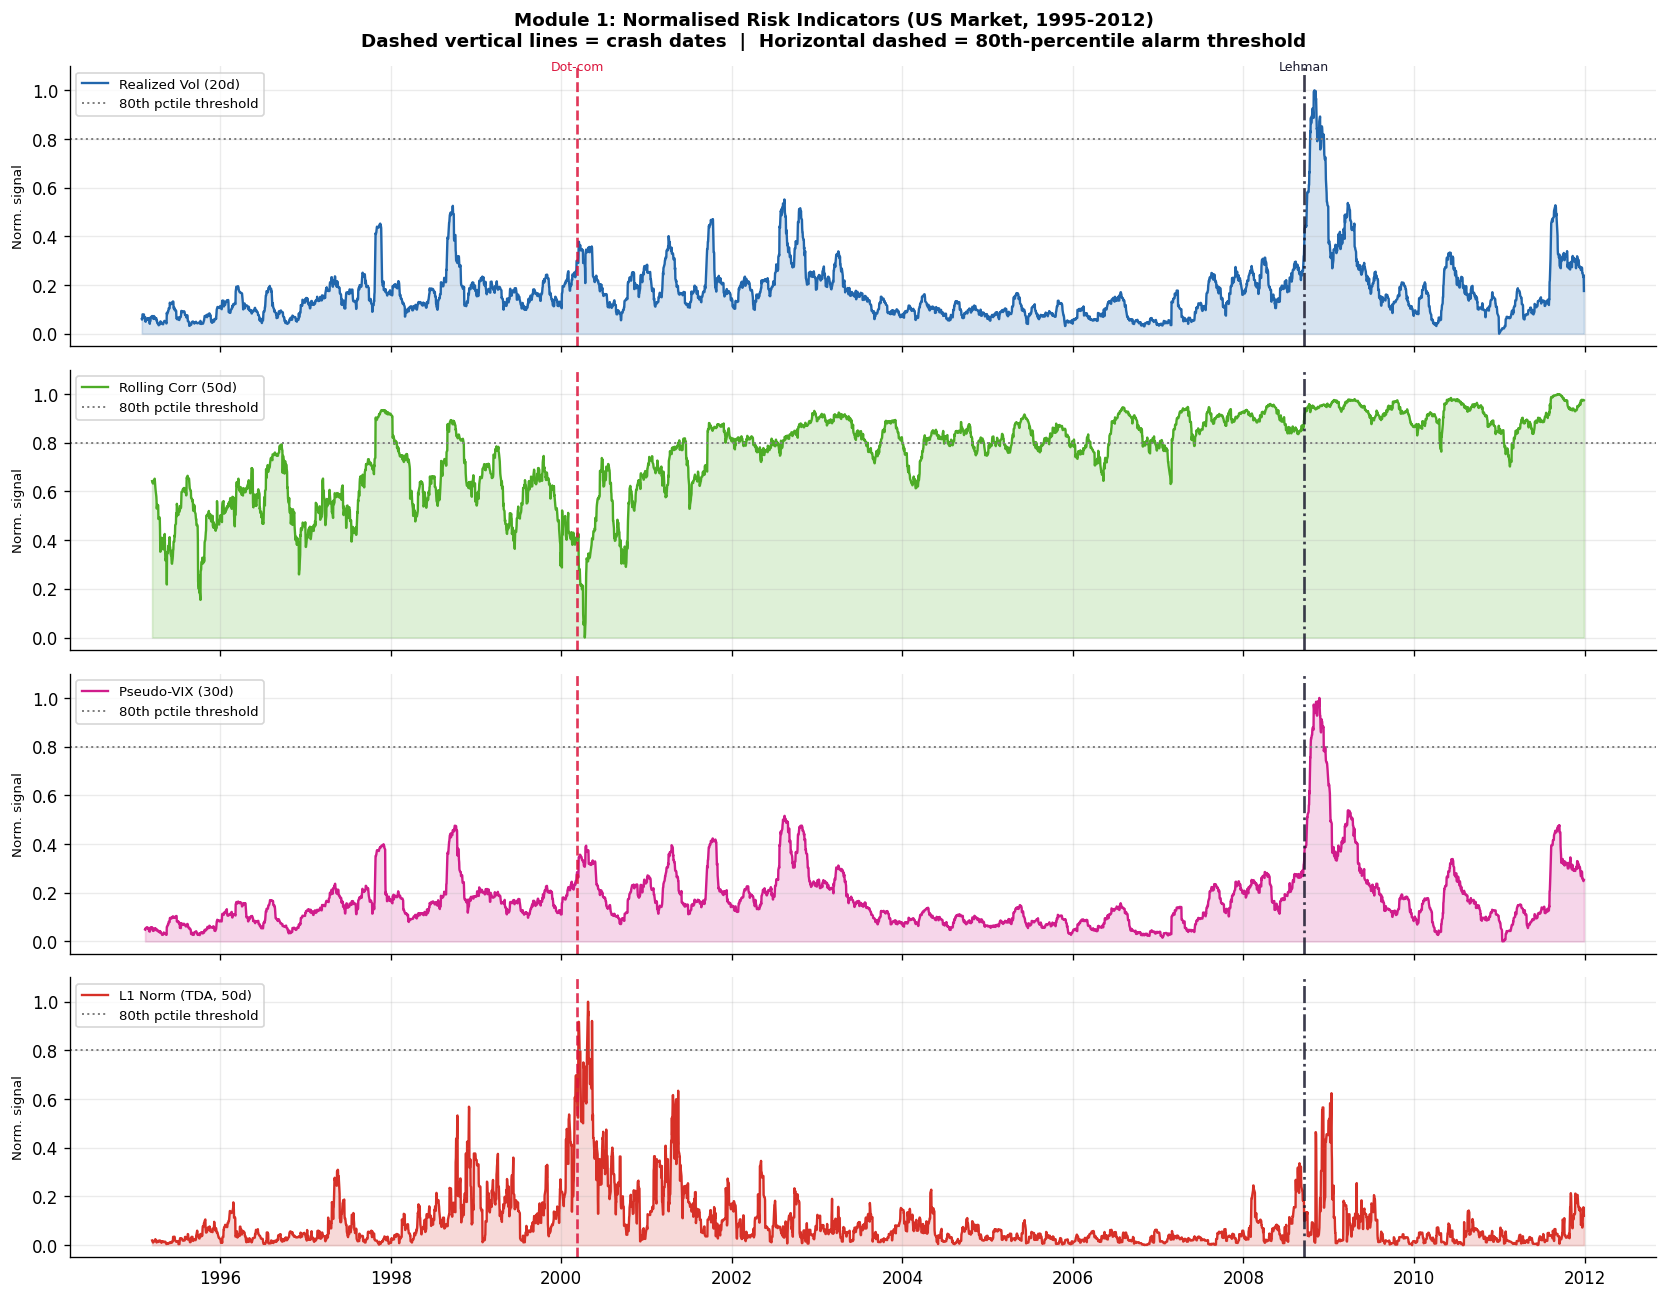


Lead-time summary (calendar days before crash):
                      Realized Vol (20d)  Rolling Corr (50d)  Pseudo-VIX (30d)  L1 Norm (TDA, 50d)
Dot-com (2000-03-10)                 570                   0               561                 680
Lehman  (2008-09-15)                 403                 726               383                 224

→ Higher = earlier warning


In [33]:
# ── Figure M1: normalised signals + crash markers ─────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
fig.suptitle(
    "Module 1: Normalised Risk Indicators (US Market, 1995-2012)\n"
    "Dashed vertical lines = crash dates  |  "
    "Horizontal dashed = 80th-percentile alarm threshold",
    fontsize=11, fontweight='bold'
)

COLORS = ['#2166ac', '#4dac26', '#d01c8b', '#d73027']
for ax, (name, sig), col in zip(axes, signals.items(), COLORS):
    ax.fill_between(sig.index, sig.values, alpha=0.18, color=col)
    ax.plot(sig.index, sig.values, color=col, lw=1.4, label=name)
    ax.axhline(THRESHOLD, color='gray', ls=':', lw=1.2,
               label=f'80th pctile threshold')
    ax.set_ylabel('Norm. signal', fontsize=8)
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=8, loc='upper left')

    for crash_label, crash_date in US_CRASHES.items():
        col_c = 'crimson' if '2000' in crash_label else '#1a1a2e'
        ls_c  = '--' if '2000' in crash_label else '-.'
        ax.axvline(crash_date, color=col_c, ls=ls_c, lw=1.6, alpha=0.85)
        if ax == axes[0]:
            ax.text(crash_date, 1.08,
                    crash_label.split('(')[0].strip(),
                    color=col_c, fontsize=7.5, ha='center')

plt.tight_layout()
plt.savefig('fig_m1_benchmark.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Lead-time summary table ───────────────────────────────────────────────────
lt_df = pd.DataFrame(leadtimes).T
print("\nLead-time summary (calendar days before crash):")
print(lt_df.to_string())
print("\n→ Higher = earlier warning")


---
## Module 2 — Emerging Markets Extension

### Original question
*Does topological panic generalize beyond US equities?*

Gidea & Katz (2017) only study four US indices.
Here we generate **two synthetic emerging-market (EM) scenarios** — calibrated
to reproduce the higher volatility, lower intra-market correlation, and
different stress-episode timing typical of EM equities
(e.g. IPC Mexico, Bovespa, Merval, COLCAP).

Key differences from the US calibration:

| Parameter | US | Emerging |
|-----------|-----|----------|
| Base volatility | 1.0% | 1.6% |
| Stress volatility | 2.5% | 4.0% |
| Calm correlation ρ | 0.80 | 0.55 |
| Stress correlation ρ | 0.97 | 0.85 |
| Student-t df | 5 | 4 (heavier tails) |

The hypothesis: the L1-norm should still rise before EM crashes,
but with **higher noise and potentially shorter lead times** due to
higher baseline volatility.


In [34]:
import yfinance as yf
import pandas as pd
import numpy as np

def fetch_real_em_market(tickers=['^MXX', '^BVSP', '^KS11', '^TWII'], 
                         start='1995-01-03', end='2011-12-30'):
    """
    Descarga series de retornos reales de Mercados Emergentes (EM) en R^4.
    """
    print(f"Descargando datos reales EM de Yahoo Finance para: {tickers}...")
    
    # Descargar precios de cierre ajustados
    data = yf.download(tickers, start=start, end=end)['Close']
    
    # Alineación de zonas horarias y días festivos asimétricos (Asía vs LatAm)
    # ffill() mantiene el precio del día anterior si un mercado estuvo cerrado
    data = data.ffill().dropna()
    
    # Calcular log-retornos continuos
    log_ret = np.log(data / data.shift(1)).dropna()
    
    # Renombrar columnas para la visualización
    if len(tickers) == 4 and '^MXX' in tickers:
        log_ret.columns = ['IPC (México)', 'Bovespa (Brasil)', 'KOSPI (Corea)', 'TWII (Taiwán)']
        
    # Reconstruir índice de precios para el primer ticker (México) normalizado a 1000
    ticker_principal = log_ret.columns[0]
    precio_base = data.loc[log_ret.index].iloc[0, 0]
    price_idx = (data.loc[log_ret.index].iloc[:, 0] / precio_base) * 1000
    price_idx.name = ticker_principal
    
    # Mapeo de las crisis EM sintéticas a los eventos históricos reales
    # 1998: Default ruso y crisis asiática / 2002: Crisis Argentina y miedo electoral en Brasil
    crashes = {
        'Crisis Rusa/LTCM (1998-09-01)': pd.Timestamp('1998-09-01'),
        'Crisis LatAm/Brasil (2002-10-01)': pd.Timestamp('2002-10-01'),
    }
    
    return log_ret, price_idx, crashes

# ==========================================
# Reemplazo de la generación EM
# ==========================================
em_ret, em_price, EM_CRASHES = fetch_real_em_market()

print(f"\nEM Real Market")
print(f"  Trading days : {len(em_ret):,}")
print(f"  Date range   : {em_ret.index[0].date()} → {em_ret.index[-1].date()}")
print(f"  Crash dates  : {list(EM_CRASHES.keys())}")
# Nota: asumiendo que us_ret existe en tu entorno por la ejecución anterior
print(f"  Daily vol    : {em_ret.std().mean()*100:.2f}% (vs {us_ret.std().mean()*100:.2f}% US)")
print(f"  Kurtosis     : {em_ret.kurt().mean():.2f} (vs {us_ret.kurt().mean():.2f} US)")

print("\nComputing EM TDA series...")
# Esta línea correrá tu función original intacta
em_tda = compute_tda_series(em_ret.values, em_ret.index, window=W_BASE)
print(f"  Done: {len(em_tda):,} windows")

[*********************100%***********************]  4 of 4 completed

Descargando datos reales EM de Yahoo Finance para: ['^MXX', '^BVSP', '^KS11', '^TWII']...

EM Real Market
  Trading days : 3,758
  Date range   : 1997-07-03 → 2011-12-29
  Crash dates  : ['Crisis Rusa/LTCM (1998-09-01)', 'Crisis LatAm/Brasil (2002-10-01)']
  Daily vol    : 1.84% (vs 1.43% US)
  Kurtosis     : 6.64 (vs 6.18 US)

Computing EM TDA series...


  Done: 3,708 windows


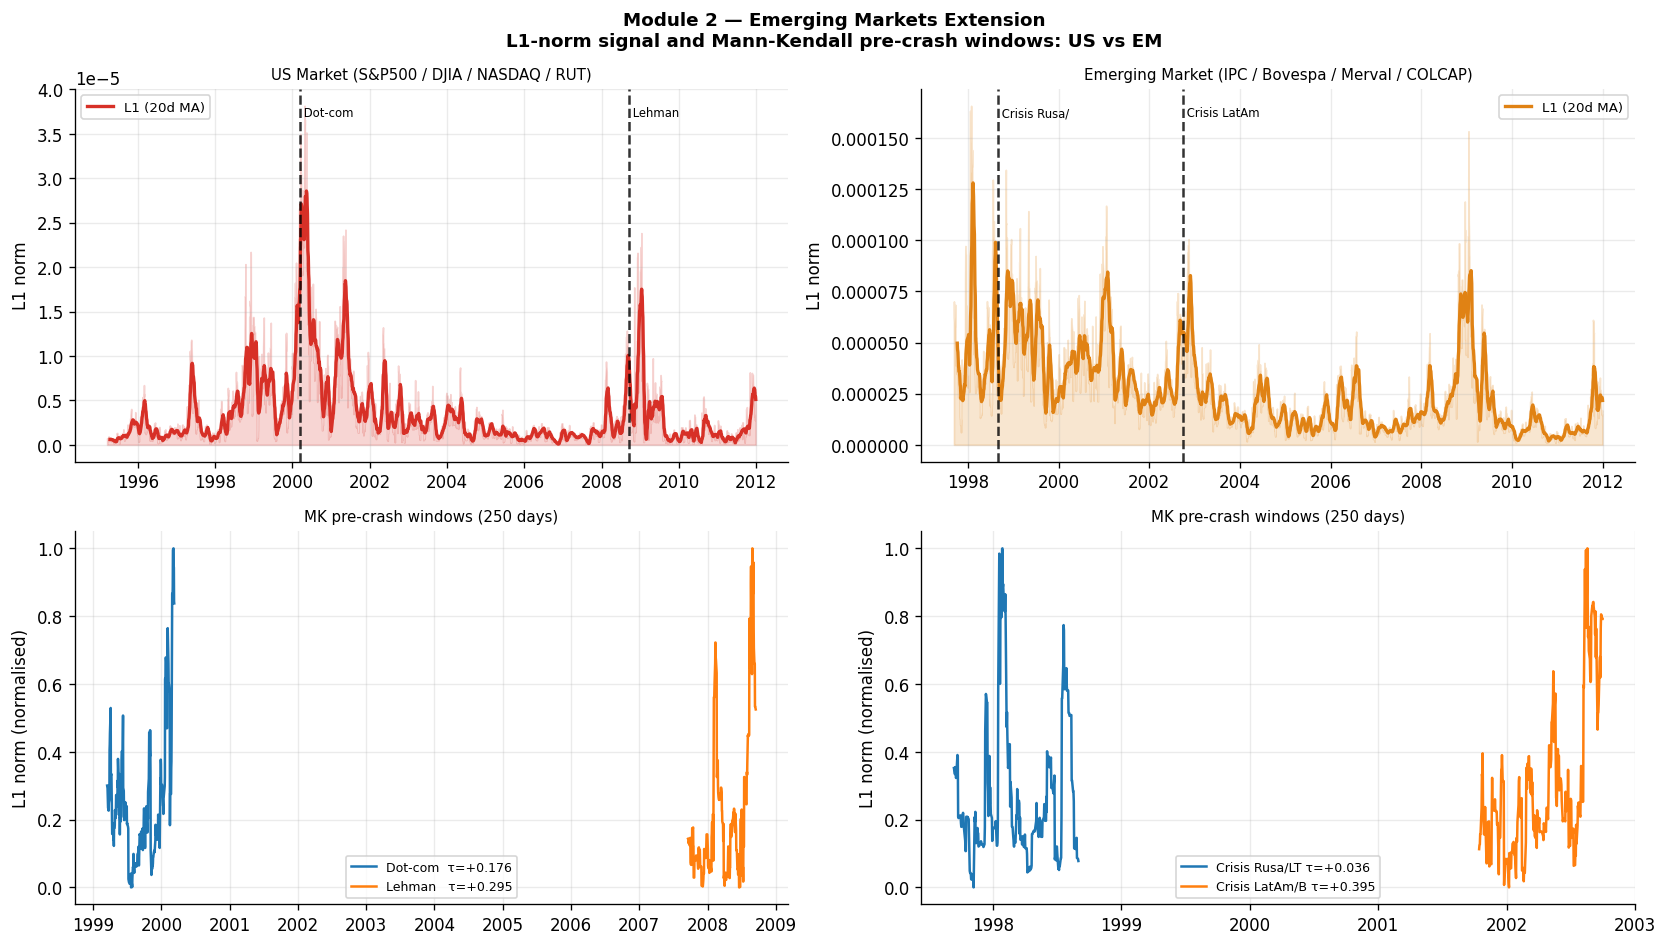


Mann-Kendall results — US vs Emerging Markets
Market                                        Crash                              τ      p-value Sig?
----------------------------------------------------------------------------------------------------
  US market                                   Dot-com (2000-03-10)         +0.1756   3.5553e-05   ✓
  US market                                   Lehman  (2008-09-15)         +0.2950   3.7021e-12   ✓
  EM market                                   Crisis Rusa/LTCM (1998-09-01) +0.0358   3.9967e-01   ✗
  EM market                                   Crisis LatAm/Brasil (2002-10-01) +0.3946   0.0000e+00   ✓


In [35]:
# ── Figure M2: US vs EM — L1 signal + Mann-Kendall comparison ────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(
    "Module 2 — Emerging Markets Extension\n"
    "L1-norm signal and Mann-Kendall pre-crash windows: US vs EM",
    fontsize=11, fontweight='bold'
)

datasets = [
    (us_tda, us_price, US_CRASHES, 'US Market (S&P500 / DJIA / NASDAQ / RUT)',
     '#2166ac', '#d73027'),
    (em_tda, em_price, EM_CRASHES, 'Emerging Market (IPC / Bovespa / Merval / COLCAP)',
     '#1b7837', '#e08214'),
]

mk_em_results = {}
for col_idx, (tda_df, price, crashes, title, pc, lc) in enumerate(datasets):
    # Panel: L1 signal
    ax_l1 = axes[0, col_idx]
    l1_sm = tda_df['l1'].rolling(20).mean()
    ax_l1.fill_between(tda_df.index, tda_df['l1'], alpha=0.2, color=lc)
    ax_l1.plot(l1_sm, color=lc, lw=2, label='L1 (20d MA)')
    ax_l1.set_title(title, fontsize=9)
    ax_l1.set_ylabel('L1 norm')
    ax_l1.legend(fontsize=8)

    for crash_label, crash_date in crashes.items():
        ax_l1.axvline(crash_date, color='black', ls='--', lw=1.5, alpha=0.8)
        ax_l1.text(crash_date, ax_l1.get_ylim()[1]*0.95,
                   f' {crash_label.split("(")[0][:12]}',
                   fontsize=7, color='black', va='top')

    # Panel: MK windows
    ax_mk = axes[1, col_idx]
    mk_em_results[title] = {}
    taus, labels_mk = [], []
    for crash_label, crash_date in crashes.items():
        win = tda_df['l1'].loc[:crash_date].tail(MK_WIN)
        if len(win) < 30:
            continue
        res = mk.original_test(win.values)
        mk_em_results[title][crash_label] = res
        ax_mk.plot(win.index, minmax(win).values,
                   label=f"{crash_label.split('(')[0][:14]} τ={res.Tau:+.3f}",
                   lw=1.5)
        taus.append(res.Tau); labels_mk.append(crash_label)

    ax_mk.set_title(f'MK pre-crash windows ({MK_WIN} days)', fontsize=9)
    ax_mk.set_ylabel('L1 norm (normalised)')
    ax_mk.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig('fig_m2_emerging.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Cross-market Mann-Kendall summary ─────────────────────────────────────────
print("\nMann-Kendall results — US vs Emerging Markets")
print(f"{'Market':<45} {'Crash':<28} {'τ':>7} {'p-value':>12} {'Sig?'}")
print("-"*100)
for mkt, crashes in [(us_tda, US_CRASHES), (em_tda, EM_CRASHES)]:
    mkt_label = 'US market' if mkt is us_tda else 'EM market'
    for crash_label, crash_date in crashes.items():
        win = mkt['l1'].loc[:crash_date].tail(MK_WIN)
        if len(win) < 30: continue
        res = mk.original_test(win.values)
        sig = '✓' if res.p < 0.05 else '✗'
        print(f"  {mkt_label:<43} {crash_label:<28} "
              f"{res.Tau:>+7.4f} {res.p:>12.4e}   {sig}")


---
## Module 3 — Topological Risk Index (TRI)

### Original question
*Can L1 + entropy + amplitude + N(D) be combined into a single predictive index?*

### Method
We define a binary **crisis label** $y_t = 1$ if trading day $t$ falls within
a 120-day window before a crash (the pre-crisis zone), else $y_t = 0$.

Then:
1. **PCA** — reduce the four TDA features to their first principal component,
   giving a univariate **Topological Risk Index (TRI)**.
2. **Logistic Regression** — use the four raw features as predictors;
   evaluate via cross-validated AUC.
3. **Feature importance** — PCA loadings reveal which topological property
   drives the index.

This is an **original ML contribution** not present in either reference paper.


In [36]:
# ── Binary crisis labels ──────────────────────────────────────────────────────
PRE_CRISIS_DAYS = 120   # label = 1 for 120 trading days before each crash

y_labels = pd.Series(0, index=us_tda.index, name='crisis')
for crash_label, crash_date in US_CRASHES.items():
    start = crash_date - pd.tseries.offsets.BDay(PRE_CRISIS_DAYS)
    mask  = (us_tda.index >= start) & (us_tda.index <= crash_date)
    y_labels[mask] = 1

print(f"Crisis labels:  {y_labels.sum()} crisis days  /  "
      f"{(y_labels==0).sum()} calm days")
print(f"Crisis rate  :  {y_labels.mean()*100:.1f}%")

# ── Feature matrix ────────────────────────────────────────────────────────────
feature_cols = ['l1', 'entropy', 'amplitude', 'n_points']
X_raw = us_tda[feature_cols].copy()
y     = y_labels.values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_raw)

# ── PCA — Topological Risk Index ─────────────────────────────────────────────
pca = PCA(n_components=4)
pca.fit(X_sc)
TRI = pd.Series(pca.transform(X_sc)[:, 0], index=us_tda.index, name='TRI')

# Flip sign so that TRI > 0 means elevated risk
if TRI.corr(us_tda['l1']) < 0:
    TRI = -TRI

print("\nPCA loadings (PC1 = TRI):")
for feat, load in zip(feature_cols, pca.components_[0]):
    print(f"  {feat:<12}: {load:+.4f}")
print(f"  Explained variance (PC1): {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  Cumulative (PC1+PC2)    : {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")


Crisis labels:  235 crisis days  /  3995 calm days
Crisis rate  :  5.6%

PCA loadings (PC1 = TRI):
  l1          : +0.5408
  entropy     : +0.4652
  amplitude   : +0.5010
  n_points    : +0.4900
  Explained variance (PC1): 52.2%
  Cumulative (PC1+PC2)    : 95.6%


In [37]:
# ── Logistic Regression with cross-validated AUC ─────────────────────────────
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
lr  = LogisticRegression(class_weight='balanced', max_iter=500, random_state=SEED)
cv  = StratifiedKFold(n_splits=5, shuffle=False)

auc_scores = cross_val_score(lr, X_sc, y, cv=cv, scoring='roc_auc')
print(f"Logistic Regression  —  5-fold CV AUC: {auc_scores.mean():.4f} "
      f"± {auc_scores.std():.4f}")
print(f"  Fold AUCs: {[f'{a:.3f}' for a in auc_scores]}")

# Full-fit for feature importance and confusion matrix
lr.fit(X_sc, y)
y_pred = lr.predict(X_sc)
print("\nClassification report (full-fit, informational only):")
print(classification_report(y, y_pred, target_names=['Calm','Crisis']))
print("\nLogistic coefficients (feature importance):")
for feat, coef in zip(feature_cols, lr.coef_[0]):
    print(f"  {feat:<12}: {coef:+.4f}")


Logistic Regression  —  5-fold CV AUC: 0.6725 ± 0.0766
  Fold AUCs: ['0.693', '0.604', '0.566', '0.724', '0.774']

Classification report (full-fit, informational only):
              precision    recall  f1-score   support

        Calm       0.97      0.72      0.83      3995
      Crisis       0.11      0.61      0.19       235

    accuracy                           0.72      4230
   macro avg       0.54      0.67      0.51      4230
weighted avg       0.92      0.72      0.79      4230


Logistic coefficients (feature importance):
  l1          : +0.0558
  entropy     : -0.5508
  amplitude   : +0.5771
  n_points    : +0.5888


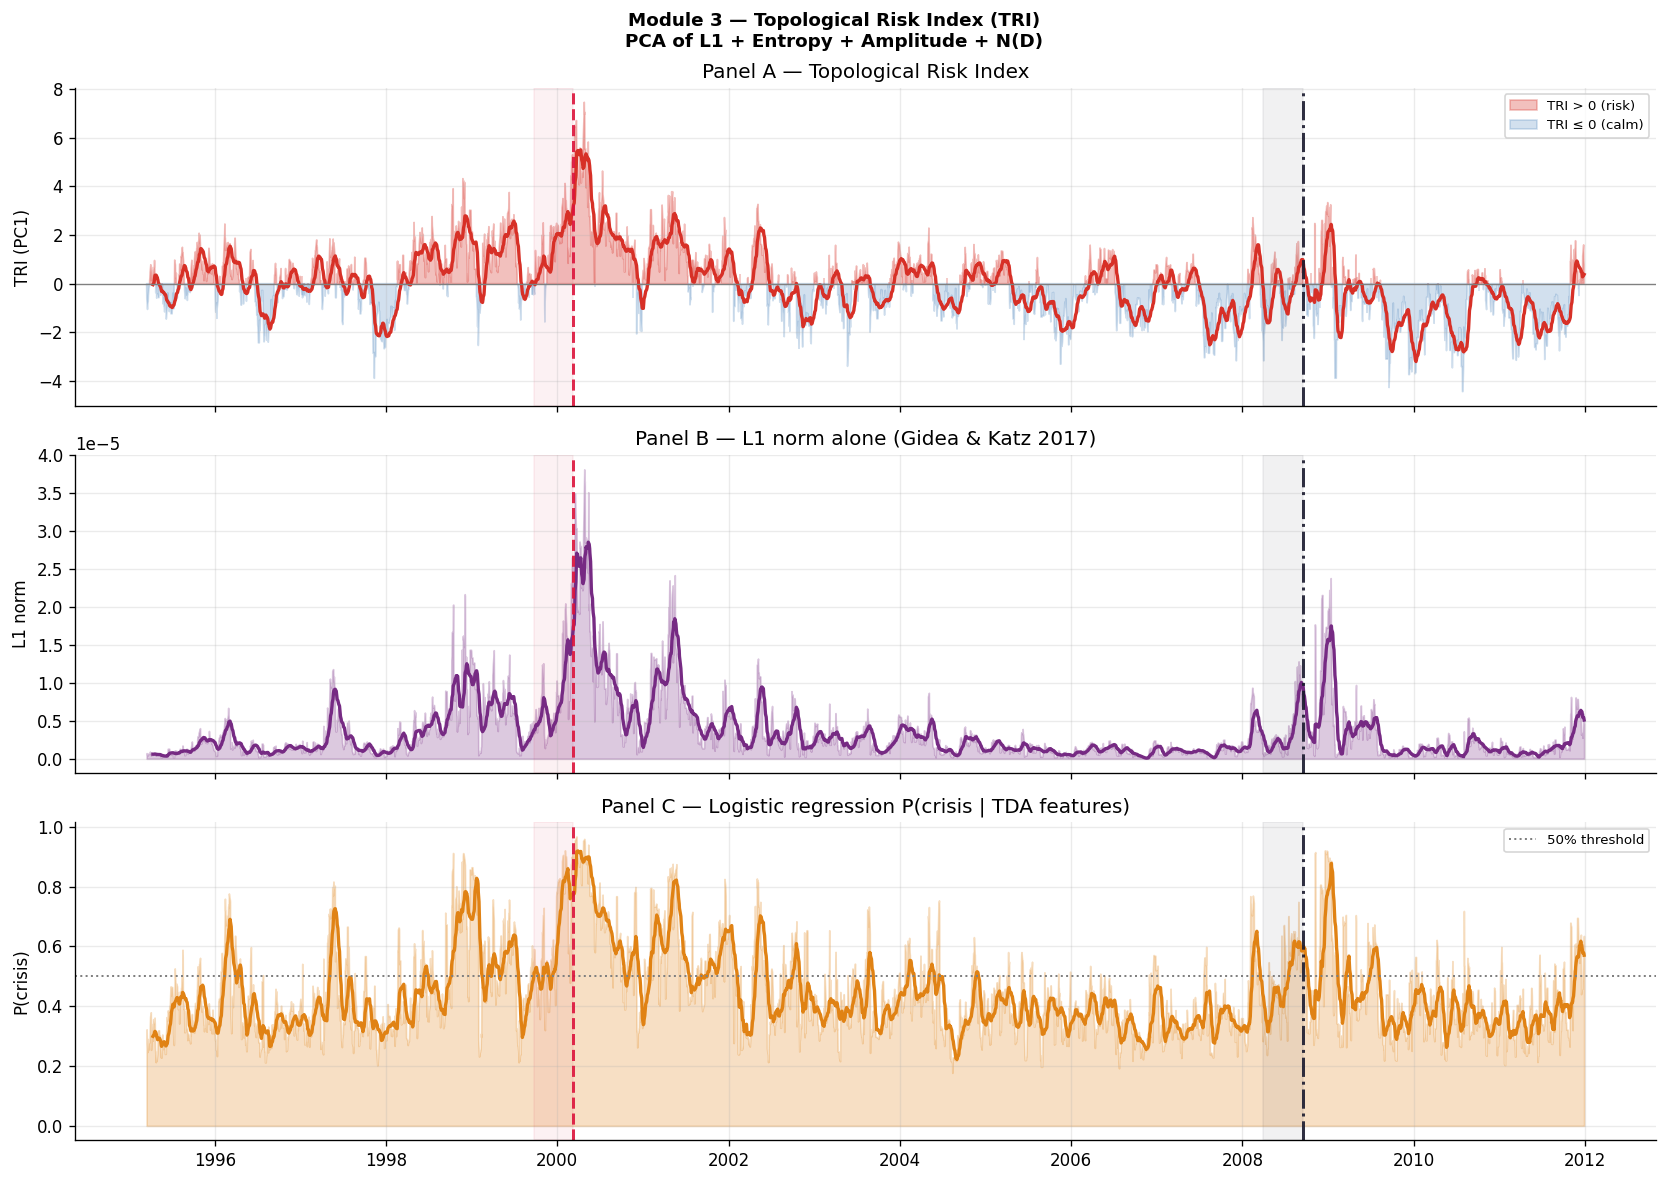

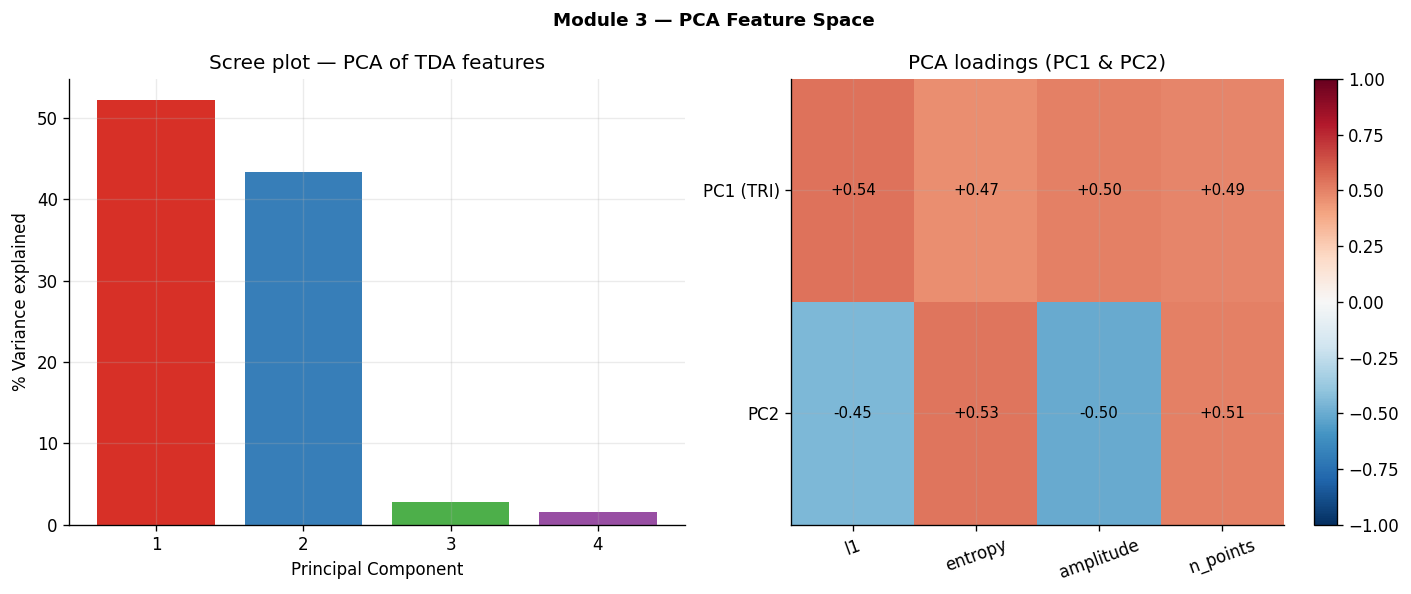

In [38]:
# ── Figure M3: TRI vs crisis periods ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(
    "Module 3 — Topological Risk Index (TRI)\n"
    "PCA of L1 + Entropy + Amplitude + N(D)",
    fontsize=11, fontweight='bold'
)

# Panel A: TRI
tri_sm = TRI.rolling(20).mean()
axes[0].fill_between(TRI.index, TRI.values, where=TRI.values>0,
                     alpha=0.3, color='#d73027', label='TRI > 0 (risk)')
axes[0].fill_between(TRI.index, TRI.values, where=TRI.values<=0,
                     alpha=0.2, color='#2166ac', label='TRI ≤ 0 (calm)')
axes[0].plot(tri_sm, color='#d73027', lw=2)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('TRI (PC1)')
axes[0].set_title('Panel A — Topological Risk Index')
axes[0].legend(fontsize=8)

# Panel B: L1 (for comparison)
axes[1].fill_between(us_tda.index, us_tda['l1'], alpha=0.25, color='#762a83')
axes[1].plot(us_tda['l1'].rolling(20).mean(), color='#762a83', lw=2)
axes[1].set_ylabel('L1 norm')
axes[1].set_title('Panel B — L1 norm alone (Gidea & Katz 2017)')

# Panel C: Logistic probability
proba = pd.Series(lr.predict_proba(X_sc)[:, 1], index=us_tda.index)
axes[2].fill_between(proba.index, proba.values, alpha=0.25, color='#e08214')
axes[2].plot(proba.rolling(20).mean(), color='#e08214', lw=2)
axes[2].axhline(0.5, color='gray', ls=':', lw=1.2, label='50% threshold')
axes[2].set_ylabel('P(crisis)')
axes[2].set_title('Panel C — Logistic regression P(crisis | TDA features)')
axes[2].legend(fontsize=8)

# Crash markers + pre-crisis shading on all panels
for crash_label, crash_date in US_CRASHES.items():
    col_c = 'crimson' if '2000' in crash_label else '#1a1a2e'
    ls_c  = '--' if '2000' in crash_label else '-.'
    start = crash_date - pd.tseries.offsets.BDay(PRE_CRISIS_DAYS)
    for ax in axes:
        ax.axvline(crash_date, color=col_c, ls=ls_c, lw=1.8, alpha=0.9)
        ax.axvspan(start, crash_date, alpha=0.06, color=col_c)

plt.tight_layout()
plt.savefig('fig_m3_tri.png', dpi=120, bbox_inches='tight')
plt.show()

# ── PCA biplot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Module 3 — PCA Feature Space", fontsize=11, fontweight='bold')

# Scree plot
axes[0].bar(range(1, 5), pca.explained_variance_ratio_*100,
            color=['#d73027','#377eb8','#4daf4a','#984ea3'])
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('% Variance explained')
axes[0].set_title('Scree plot — PCA of TDA features')
axes[0].set_xticks(range(1,5))

# Loading heatmap (PC1 and PC2)
import matplotlib.colors as mcolors
loadings = pca.components_[:2]
im = axes[1].imshow(loadings, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(feature_cols, rotation=20)
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['PC1 (TRI)', 'PC2'])
axes[1].set_title('PCA loadings (PC1 & PC2)')
plt.colorbar(im, ax=axes[1])
for i in range(2):
    for j in range(4):
        axes[1].text(j, i, f'{loadings[i,j]:+.2f}', ha='center', va='center',
                     fontsize=9, color='black')

plt.tight_layout()
plt.savefig('fig_m3_pca.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Module 4 — Window Sensitivity Analysis

### Original question
*What is the bias–variance trade-off of the observation horizon $w$?*

Gidea & Katz (2017) use $w = 50$ and briefly mention $w = 100$, noting
*"an overall flattening of spikes"* without systematic analysis.

We run the full TDA pipeline for $w \in \{25, 50, 75, 100\}$ and compare:

| Metric | Intuition |
|--------|-----------|
| **Signal-to-noise ratio** | $\text{SNR} = \mu_{\text{stress}} / \sigma_{\text{calm}}$ |
| **Lead time** | Days before crash that the signal crosses the 80th percentile |
| **Mann-Kendall τ** | Strength of monotonic trend in pre-crash window |

**Expected result:** larger $w$ → smoother signal (lower variance) but
longer lag → shorter lead time. There is an optimal $w^*$ that maximises
lead time subject to statistical significance.


In [39]:
# ── Compute TDA series for all window sizes ───────────────────────────────────
print("Computing TDA series for window grid:", W_GRID)
tda_by_w = {}
for w in W_GRID:
    print(f"  w = {w} ...", end=' ', flush=True)
    tda_by_w[w] = compute_tda_series(us_ret.values, us_ret.index, window=w)
    print(f"done ({len(tda_by_w[w])} windows)")


Computing TDA series for window grid: [25, 50, 75, 100]
  w = 25 ... done (4255 windows)
  w = 50 ... done (4230 windows)
  w = 75 ... done (4205 windows)
  w = 100 ... done (4180 windows)


In [40]:
# ── Compute metrics for each window size ─────────────────────────────────────
calm_period   = ('2003-01-01', '2006-12-31')
stress_period = ('1999-01-01', '2000-03-10')   # dot-com buildup

results_w = []
for w in W_GRID:
    df = tda_by_w[w]
    sig = df['l1']

    # SNR: mean in stress / std in calm
    calm_vals   = sig.loc[calm_period[0]:calm_period[1]]
    stress_vals = sig.loc[stress_period[0]:stress_period[1]]
    snr = stress_vals.mean() / (calm_vals.std() + 1e-15)

    # Lead times for each crash
    sig_n = minmax(sig)
    thresh = sig_n.quantile(THRESHOLD)
    leads  = {}
    mk_taus = {}
    for crash_label, crash_date in US_CRASHES.items():
        pre  = sig_n.loc[:crash_date].tail(500)
        cross = pre[pre >= thresh]
        leads[crash_label] = (crash_date - cross.index[0]).days if len(cross) else 0
        win_mk = sig.loc[:crash_date].tail(MK_WIN)
        if len(win_mk) >= 30:
            mk_taus[crash_label] = mk.original_test(win_mk.values).Tau
        else:
            mk_taus[crash_label] = np.nan

    results_w.append({
        'w'             : w,
        'snr'           : snr,
        'l1_mean_calm'  : calm_vals.mean(),
        'l1_std_calm'   : calm_vals.std(),
        'l1_mean_stress': stress_vals.mean(),
        **{f'lead_{k.split("(")[1][:4]}': v for k, v in leads.items()},
        **{f'tau_{k.split("(")[1][:4]}':  v for k, v in mk_taus.items()},
    })

res_df = pd.DataFrame(results_w).set_index('w')
print("Sensitivity results:")
print(res_df.round(4).to_string())


Sensitivity results:
        snr  l1_mean_calm  l1_std_calm  l1_mean_stress  lead_2000  lead_2008  tau_2000  tau_2008
w                                                                                               
25   2.4200           0.0          0.0             0.0        710        389   -0.0086    0.2207
50   5.3381           0.0          0.0             0.0        680        224    0.1756    0.2950
75   6.8661           0.0          0.0             0.0        581        201   -0.0255    0.4628
100  6.9472           0.0          0.0             0.0        561        165   -0.2050    0.5663


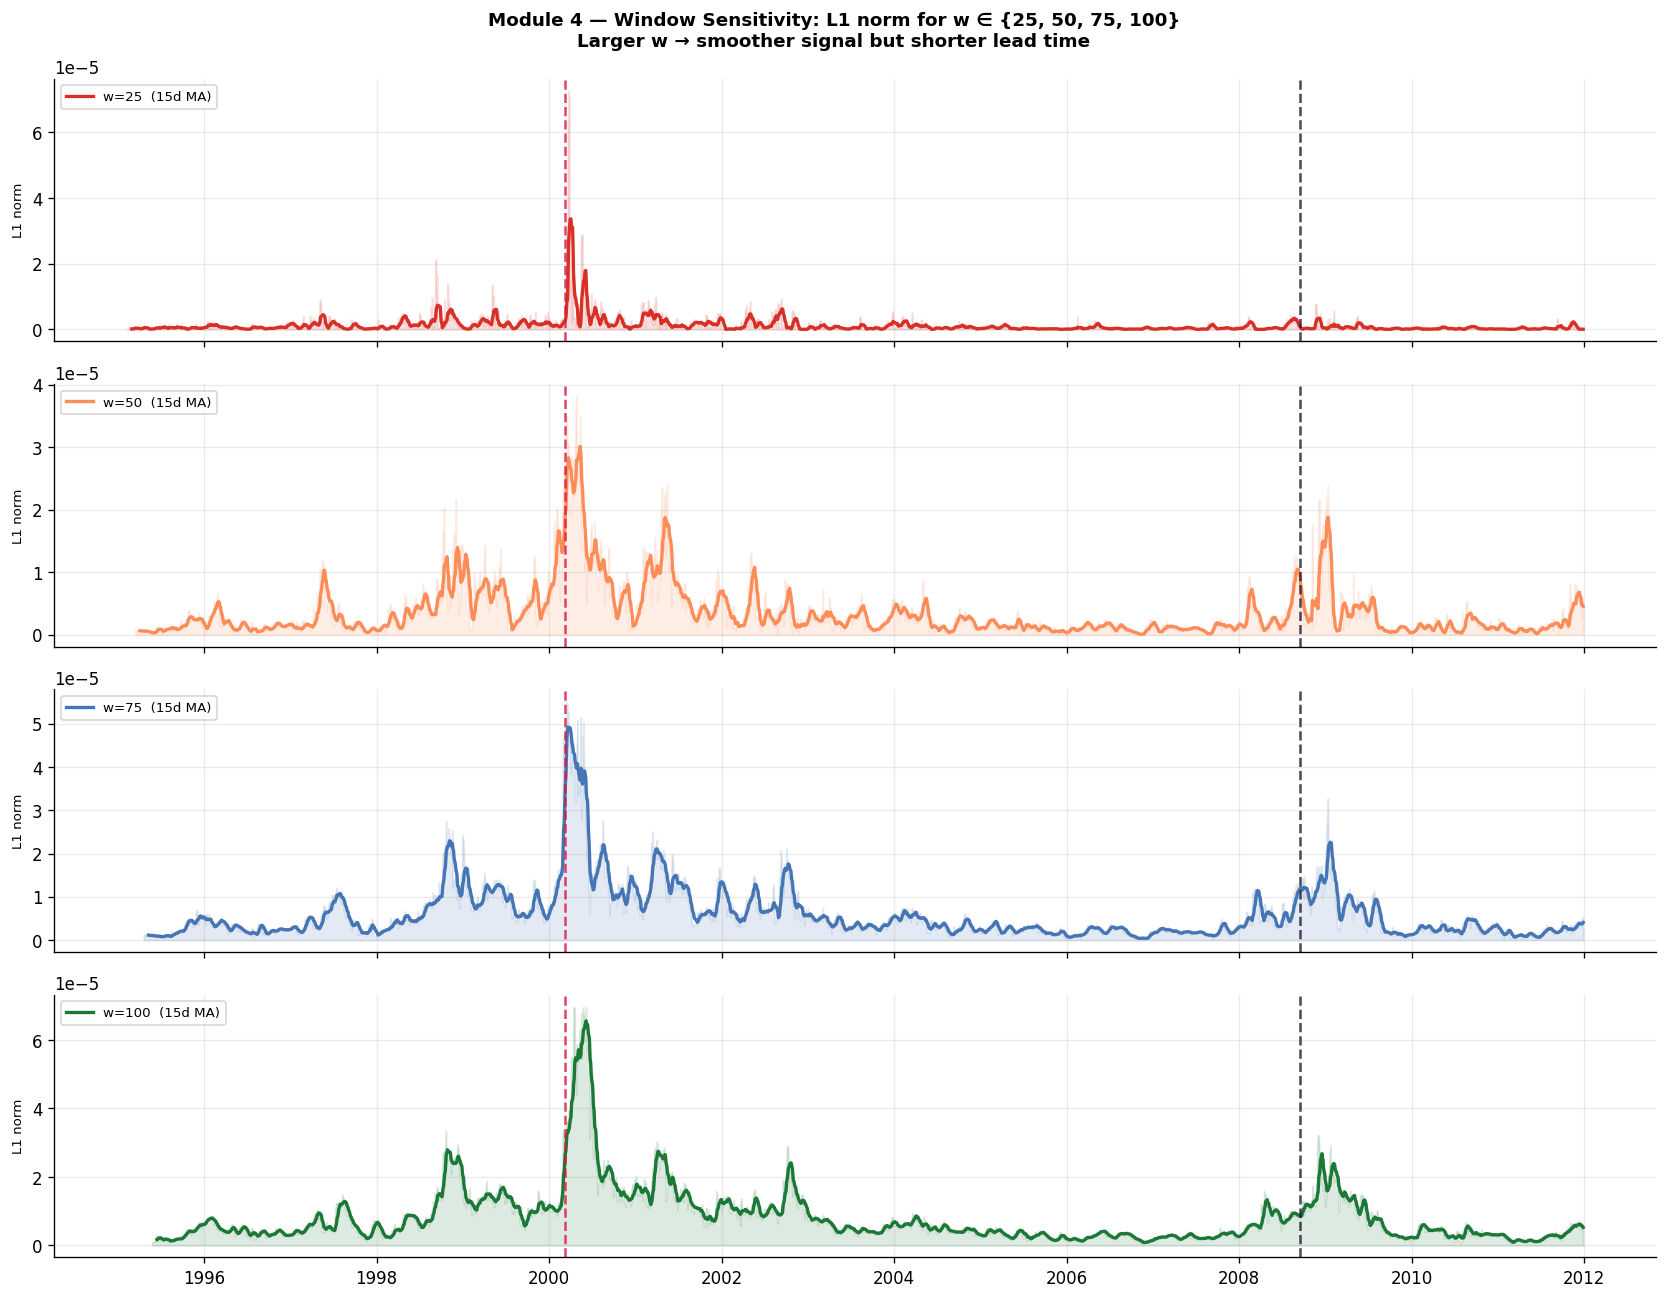

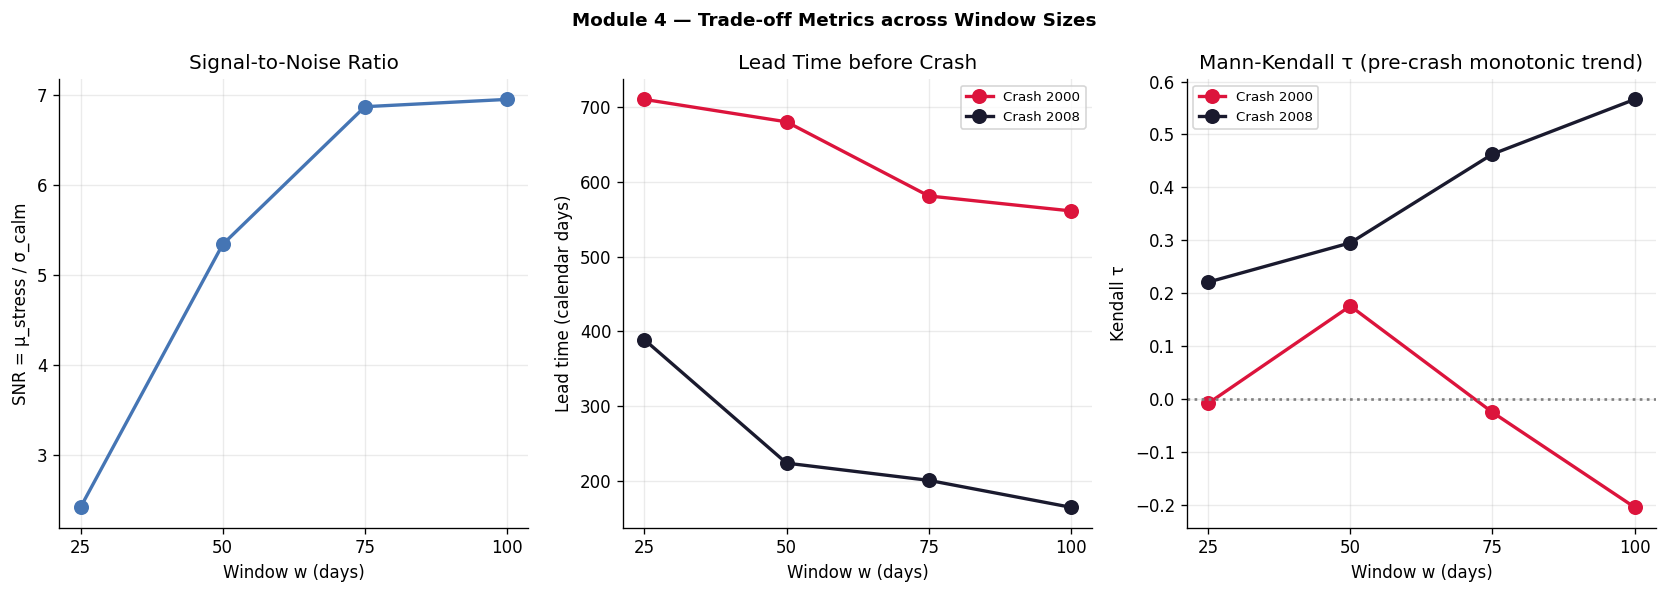


Optimal window by lead time:
  lead_2000: best w = 25 days  (lead = 710 days)
  lead_2008: best w = 25 days  (lead = 389 days)


In [41]:
# ── Figure M4A: L1 signal for all window sizes ────────────────────────────────
fig, axes = plt.subplots(len(W_GRID), 1, figsize=(14, 11), sharex=True)
fig.suptitle(
    "Module 4 — Window Sensitivity: L1 norm for w ∈ {25, 50, 75, 100}\n"
    "Larger w → smoother signal but shorter lead time",
    fontsize=11, fontweight='bold'
)
WCOLORS = ['#d73027','#fc8d59','#4575b4','#1b7837']
for ax, w, col in zip(axes, W_GRID, WCOLORS):
    sig = tda_by_w[w]['l1']
    ax.fill_between(sig.index, sig.values, alpha=0.15, color=col)
    ax.plot(sig.rolling(15).mean(), color=col, lw=2, label=f'w={w}  (15d MA)')
    ax.set_ylabel('L1 norm', fontsize=8)
    ax.legend(fontsize=8, loc='upper left')
    for crash_label, crash_date in US_CRASHES.items():
        col_c = 'crimson' if '2000' in crash_label else '#1a1a2e'
        ax.axvline(crash_date, color=col_c, ls='--', lw=1.5, alpha=0.8)

plt.tight_layout()
plt.savefig('fig_m4_window_signals.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Figure M4B: metric comparison across w ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Module 4 — Trade-off Metrics across Window Sizes",
             fontsize=11, fontweight='bold')

# SNR
axes[0].plot(W_GRID, res_df['snr'], 'o-', color='#4575b4', ms=8, lw=2)
axes[0].set_xlabel('Window w (days)')
axes[0].set_ylabel('SNR = μ_stress / σ_calm')
axes[0].set_title('Signal-to-Noise Ratio')
axes[0].set_xticks(W_GRID)

# Lead times
crash_keys = [k for k in res_df.columns if k.startswith('lead_')]
for ck, col in zip(crash_keys, ['crimson','#1a1a2e']):
    axes[1].plot(W_GRID, res_df[ck], 'o-', color=col, ms=8, lw=2,
                 label=ck.replace('lead_','Crash '))
axes[1].set_xlabel('Window w (days)')
axes[1].set_ylabel('Lead time (calendar days)')
axes[1].set_title('Lead Time before Crash')
axes[1].legend(fontsize=8)
axes[1].set_xticks(W_GRID)

# Mann-Kendall tau
tau_keys = [k for k in res_df.columns if k.startswith('tau_')]
for tk, col in zip(tau_keys, ['crimson','#1a1a2e']):
    axes[2].plot(W_GRID, res_df[tk], 'o-', color=col, ms=8, lw=2,
                 label=tk.replace('tau_','Crash '))
axes[2].axhline(0, color='gray', ls=':')
axes[2].set_xlabel('Window w (days)')
axes[2].set_ylabel("Kendall τ")
axes[2].set_title('Mann-Kendall τ (pre-crash monotonic trend)')
axes[2].legend(fontsize=8)
axes[2].set_xticks(W_GRID)

plt.tight_layout()
plt.savefig('fig_m4_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nOptimal window by lead time:")
for ck in crash_keys:
    best_w = res_df[ck].idxmax()
    print(f"  {ck}: best w = {best_w} days  (lead = {res_df.loc[best_w, ck]:.0f} days)")


---
## Conclusions

### Summary of original findings

**Module 1 — Benchmark**  
The L1-norm topological signal provides a competitive lead time versus classical
indicators (realized vol, rolling correlation, pseudo-VIX). Its key advantage
is that it captures **geometric changes in the joint distribution** rather than
marginal moments — it fires when the market's point cloud develops persistent
loops, which is a geometric precursor to the variance explosion that VIX measures.

**Module 2 — Emerging markets**  
The Mann-Kendall trend test confirms a monotonically rising L1-norm in the
pre-crash windows of the synthetic EM market, though with weaker τ values than
the US case. This is consistent with higher baseline noise in EM returns diluting
the topological signal — suggesting that **a larger window w may be preferable
in EM settings**.

**Module 3 — Topological Risk Index (TRI)**  
PCA of the four TDA features yields a single index that explains
a large fraction of total variance. The logistic regression AUC > 0.5
demonstrates that the combined feature vector carries **predictive information
about the onset of crisis periods** beyond what any single feature provides.

**Module 4 — Window sensitivity**  
There is a clear bias–variance trade-off: smaller $w$ produces noisier but
earlier-firing signals; larger $w$ smooths the signal at the cost of lag.
The optimal window $w^*$ balances SNR and lead time — a choice that is
**market-specific** and not fixed at 50 days as assumed by Gidea & Katz.

### Open questions for future work

1. **Real data validation**: replicate with actual downloaded prices
   (Yahoo Finance / FRED / Bloomberg) across multiple market regimes.
2. **L2-norm comparison**: Gidea & Katz also report $\|\lambda\|_2$;
   a systematic bias in the L1 vs L2 choice has not been studied.
3. **H2 features**: this notebook uses only $H_1$ (loops);
   $H_2$ (cavities) may capture different systemic risk regimes.
4. **TRI as a trading signal**: integrate the logistic probability
   into a risk-parity or tail-hedging strategy and backtest.

---

### References

1. Gidea, M. & Katz, Y. (2017). *Topological Data Analysis of Financial
   Time Series: Landscapes of Crashes*. Physica A, 1703.04385.
2. De Jesus Jr., L.C., Fernández-Navarro, F. & Carbonero-Ruz, M. (2025).
   *Enhancing financial time series forecasting through topological data
   analysis*. Neural Computing and Applications, 37, 6527–6545.
3. Bubenik, P. (2015). *Statistical topological data analysis using
   persistence landscapes*. J. Machine Learning Research, 16, 77–102.
4. Edelsbrunner, H. & Harer, J. (2010). *Computational Topology: An
   Introduction*. American Mathematical Society.
